In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import random

In [2]:
# b. Load and Preprocess Data (MNIST dataset)
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
print("Train set shape:", X_train.shape)   # (60000, 28, 28)
print("Test set shape:", X_test.shape)     # (10000, 28, 28)

Train set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)


In [4]:
# Normalize values to [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [7]:
# Reshape to (n_samples, 28, 28, 1) for CNN
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))

In [8]:
print("Reshaped train set:", X_train.shape)  # (60000, 28, 28, 1)

Reshaped train set: (60000, 28, 28, 1)


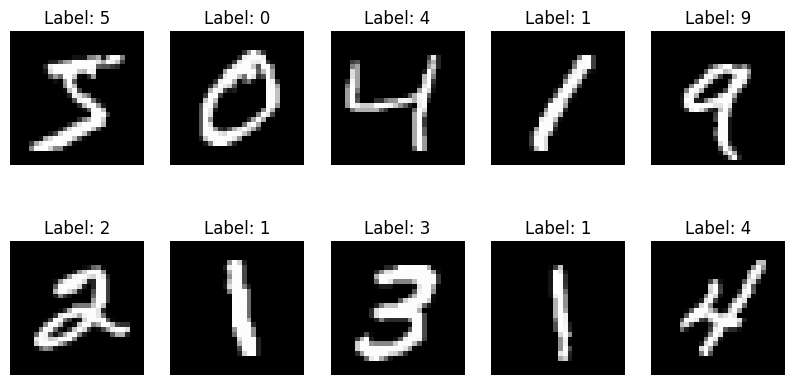

In [9]:
# Plot sample images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

In [10]:
# c. Define CNN Model Architecture (modified / deeper version)
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),  # conv layer 1
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation="relu"),  # conv layer 2
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation="relu"),          # fully connected layer
    Dense(10, activation="softmax")         # output layer
])

C:\Users\adity\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile model
optimizer = SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# d. Train Model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=2
)

Epoch 1/10
1875/1875 - 12s - 6ms/step - accuracy: 0.9429 - loss: 0.1859 - val_accuracy: 0.9823 - val_loss: 0.0547
Epoch 2/10
1875/1875 - 11s - 6ms/step - accuracy: 0.9840 - loss: 0.0529 - val_accuracy: 0.9863 - val_loss: 0.0444
Epoch 3/10
1875/1875 - 11s - 6ms/step - accuracy: 0.9884 - loss: 0.0373 - val_accuracy: 0.9899 - val_loss: 0.0321
Epoch 4/10
1875/1875 - 11s - 6ms/step - accuracy: 0.9917 - loss: 0.0270 - val_accuracy: 0.9891 - val_loss: 0.0333
Epoch 5/10
1875/1875 - 11s - 6ms/step - accuracy: 0.9938 - loss: 0.0202 - val_accuracy: 0.9892 - val_loss: 0.0332
Epoch 6/10
1875/1875 - 10s - 6ms/step - accuracy: 0.9947 - loss: 0.0168 - val_accuracy: 0.9904 - val_loss: 0.0294
Epoch 7/10
1875/1875 - 11s - 6ms/step - accuracy: 0.9959 - loss: 0.0125 - val_accuracy: 0.9918 - val_loss: 0.0278
Epoch 8/10
1875/1875 - 11s - 6ms/step - accuracy: 0.9966 - loss: 0.0098 - val_accuracy: 0.9910 - val_loss: 0.0278
Epoch 9/10
1875/1875 - 11s - 6ms/step - accuracy: 0.9979 - loss: 0.0076 - val_accuracy: 

In [13]:
# e. Evaluate Model
score = model.evaluate(X_test, y_test, verbose=0)
print("\nTest Loss:", score[0])
print("Test Accuracy:", score[1])


Test Loss: 0.037180427461862564
Test Accuracy: 0.9896000027656555


In [14]:
# Predictions on test set
predictions = np.argmax(model.predict(X_test), axis=-1)
print("Sklearn Accuracy:", accuracy_score(y_test, predictions))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Sklearn Accuracy: 0.9896


In [15]:
# Plot accuracy and loss curves
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'Training vs Validation Accuracy')

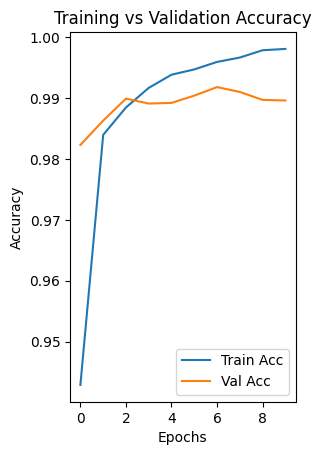

In [16]:
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()
plt.title("Training vs Validation Accuracy")

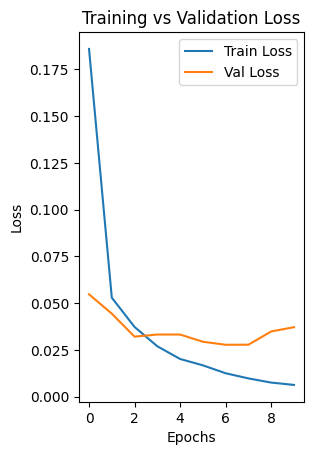

In [17]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.title("Training vs Validation Loss")

plt.show()